# Intervention Analysis

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

results = pd.read_csv(DATA_DIR / "intervention_results.csv")
results.head()

,topology,strategy,fraction,trial,n,beta,gamma,t10,t50,peak_infected,auc,final_size,duration
0,ER,none,0.0,0,1000,0.15,0.05,6,10.0,706,19207.5,0.986,153
1,ER,none,0.0,1,1000,0.15,0.05,5,9.0,725,20140.5,0.987,167
2,ER,none,0.0,2,1000,0.15,0.05,5,9.0,746,20514.5,0.994,140
3,ER,none,0.0,3,1000,0.15,0.05,7,11.0,711,19102.5,0.991,136
4,ER,none,0.0,4,1000,0.15,0.05,6,10.0,720,19185.5,0.991,162


In [2]:
summary = results.groupby(["topology", "strategy", "fraction"])[[
    "t50",
    "peak_infected",
    "final_size",
    "auc"
]].agg(["mean", "std"])

summary

t50           peak_infected             \
                                    mean       std          mean        std   
topology strategy    fraction                                                 
BA       betweenness 0.01      10.910000  1.272038        677.72  17.091010   
                     0.05      19.612903  2.591928        537.45  21.350076   
                     0.10            NaN       NaN        387.78  25.799765   
         degree      0.01      10.820000  1.217548        679.21  16.720697   
                     0.05      19.706522  2.078345        531.02  21.303473   
                     0.10            NaN       NaN        369.49  27.939869   
         none        0.00       7.900000  1.000000        738.21  15.577305   
         random      0.01       8.000000  1.005038        726.82  14.642114   
                     0.05       8.480000  1.058682        685.50  18.443197   
                     0.10       8.960000  0.941952        636.15  16.405453   
ER       betweenness 0.01      10.850000  1.048086        713.67  16.439700   
                     0.05      12.490000  1.218502        655.82  16.019798   
                     0.10      15.280000  1.436044        588.14  17.019312   
         degree      0.01      10.830000  0.932630        713.23  17.421022   
                     0.05      12.570000  1.066051        655.42  16.603018   
                     0.10      15.420000  1.342243        587.20  16.238127   
         none        0.00      10.410000  0.888706        728.26  15.224661   
         random      0.01      10.390000  0.886430        719.97  18.237743   
                     0.05      10.990000  0.948098        679.26  15.212714   
                     0.10      12.020000  1.136893        629.87  13.888194   
WS       betweenness 0.01      19.000000  1.595448        618.77  20.950570   
                     0.05      23.423913  2.409841        542.45  25.823556   
                     0.10      25.250000  2.217356        453.70  29.871611   
         degree      0.01      18.900000  1.941050        620.17  24.618731   
                     0.05      22.625000  2.318121        546.48  24.042673   
                     0.10      27.400000  2.509980        446.26  27.908805   
         none        0.00      17.760000  1.511705        639.02  21.357931   
         random      0.01      17.850000  1.684001        630.05  19.493265   
                     0.05      19.880000  1.659256        589.57  21.477381   
                     0.10      22.285714  2.417663        528.39  26.246653   

                              final_size                 auc              
                                    mean       std      mean         std  
topology strategy    fraction                                             
BA       betweenness 0.01        0.97416  0.004505  19404.45  640.014763  
                     0.05        0.89182  0.009713  17798.83  724.906808  
                     0.10        0.77102  0.018141  15485.26  709.155695  
         degree      0.01        0.97450  0.004416  19413.86  649.113670  
                     0.05        0.88738  0.010834  17657.20  738.406536  
                     0.10        0.75730  0.018853  15190.88  787.032013  
         none        0.00        0.99501  0.002699  19825.07  676.544970  
         random      0.01        0.98451  0.002376  19610.31  666.467162  
                     0.05        0.94166  0.003983  18787.33  549.044883  
                     0.10        0.88809  0.004248  17729.71  569.368413  
ER       betweenness 0.01        0.97906  0.003296  19614.06  620.398004  
                     0.05        0.93484  0.004412  18728.96  518.576576  
                     0.10        0.87646  0.005102  17552.30  600.904487  
         degree      0.01        0.97922  0.003404  19593.02  577.706813  
                     0.05        0.93495  0.003976  18727.03  502.087369  
                     0.10        0.87688  0.004981  17576.63  529.981163  
    

In [3]:
fraction_5 = results[results["fraction"] == 0.05]

t50_table = fraction_5.pivot_table(
    index="topology",
    columns="strategy",
    values="t50",
    aggfunc="mean"
)

t50_table

strategy,betweenness,degree,random
topology,,,
BA,19.612903,19.706522,8.48
ER,12.490000,12.570000,10.99
WS,23.423913,22.625000,19.88


<Figure size 640x480 with 0 Axes>

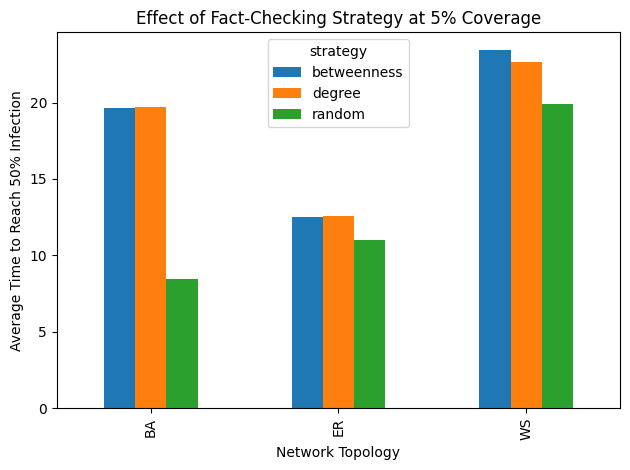

In [4]:
fraction_5 = results[results["fraction"] == 0.05]

plot_data = fraction_5.groupby(["topology", "strategy"])["t50"].mean().unstack()

plt.figure()
plot_data.plot(kind="bar")
plt.ylabel("Average Time to Reach 50% Infection")
plt.xlabel("Network Topology")
plt.title("Effect of Fact-Checking Strategy at 5% Coverage")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "intervention_t50_5percent.png", dpi=300)
plt.show()